# Universal Olfactory NER Experiments

This notebook allows running Olfaction-inspired NER experiments across different datasets (CoNLL-2003, WikiANN, etc.) and languages using a unified framework.

**Architecture:**
- **Receptor Layer:** Specialized feature detectors inspired by olfactory receptors.
- **Glomerular Layer:** Aggregates receptor activations.
- **BiLSTM-CRF:** Standard backbone for NER.

In [1]:
# @title 1. Configuration & Setup
# ==============================================================================

# ------------------------------------------------------------------------------
# USER INPUTS - CHANGE THESE
# ------------------------------------------------------------------------------
MOUNT_DRIVE = True         # Set to True to save results to Google Drive

# Select experiments to run
# ------------------------------------------------------------------------------

import os
import sys
import shutil

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Mount Drive if requested
if MOUNT_DRIVE and IN_COLAB:
    try:
        # force_remount=True fixes 'Mountpoint must not already contain files' error
        drive.mount('/content/drive', force_remount=True)
        BASE_SAVE_DIR = '/content/drive/My Drive/olfaction_inspired_ner'
    except Exception as e:
        print(f"Warning: Failed to mount Drive ({e}). Using local storage.")
        BASE_SAVE_DIR = './results'
elif MOUNT_DRIVE and not IN_COLAB:
    print("Info: MOUNT_DRIVE=True but running locally. Using local storage.")
    BASE_SAVE_DIR = './results'
else:
    BASE_SAVE_DIR = './results'

print(f"Results will be saved to: {BASE_SAVE_DIR}")

# Git Setup
import getpass

# Check if we are already in the project root (e.g. local execution)
if os.path.exists('src/train_universal.py') and os.path.exists('config/universal_config.yaml'):
    print("Already in project root.")
elif os.path.exists('olfaction-inspired-ner'):
    %cd olfaction-inspired-ner
    !git pull
else:
    # Clone using token
    print("Please provide your GitHub Personal Access Token to clone the private repository.")
    token = getpass.getpass('Enter your GitHub Personal Access Token: ')
    !git clone https://{token}@github.com/bhushan1729/olfaction-inspired-ner.git
    %cd olfaction-inspired-ner

# Install dependencies
!pip install datasets pyyaml seqeval

# Add src to path
sys.path.append(os.getcwd())

Mounted at /content/drive
Results will be saved to: /content/drive/My Drive/olfaction_inspired_ner
Please provide your GitHub Personal Access Token to clone the private repository.
Enter your GitHub Personal Access Token: ··········
Cloning into 'olfaction-inspired-ner'...
remote: Enumerating objects: 408, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 408 (delta 4), reused 11 (delta 4), pack-reused 392 (from 1)
Receiving objects: 100% (408/408), 27.82 MiB | 24.55 MiB/s, done.
Resolving deltas: 100% (184/184), done.
/content/olfaction-inspired-ner
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=a5c095afc9ad70506dc19cb5dbd8b99f590b6d83026b93eda2a4fc313c90e04b
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d

In [ ]:
    # Get your token securely (won't be visible in output)
token = getpass.getpass('Enter your GitHub Personal Access Token: ')

    # Clone using token
!git clone https://{token}@github.com/bhushan1729/olfaction-inspired-ner.git
%cd olfaction-inspired-ner

In [2]:
# Patch src/train_universal.py to remove 'verbose=True'
fn = 'src/train_universal.py'
with open(fn, 'r') as f:
    content = f.read()

if 'verbose=True' in content:
    print(f"Patching {fn}...")
    content = content.replace(', verbose=True', '')
    with open(fn, 'w') as f:
        f.write(content)
    print("Success: Removed verbose=True argument.")
else:
    print(f"{fn} already patched or 'verbose=True' not found.")

Patching src/train_universal.py...
Success: Removed verbose=True argument.


In [3]:
# @title Run ALL Experiments (All Languages)
import os
import yaml

CONFIG_PATH = 'config/universal_config.yaml'
BASE_SAVE_DIR = '/content/drive/My Drive/olfaction_inspired_ner' if os.path.exists('/content/drive') else './results'

# 1. Load Config to get all experiments
with open(CONFIG_PATH, 'r') as f:
    full_config = yaml.safe_load(f)

# Get all experiment keys
all_experiments = list(full_config['experiments'].keys())

# Define Datasets
DATASETS = ['conll_en', 'wikiann_hi', 'wikiann_mr', 'wikiann_ta']

print(f"Running on Datasets: {DATASETS}")
print(f"Running Experiments: {all_experiments}")

for dataset_key in DATASETS:
    print(f"\n{'#'*80}")
    print(f"PROCESSING DATASET: {dataset_key}")
    print(f"{'#'*80}")
    
    for exp in all_experiments:
        print(f"\n>>> Running Experiment: {exp} on {dataset_key} <<<")
        
        !python src/train_universal.py \
            --config {CONFIG_PATH} \
            --dataset_key {dataset_key} \
            --experiment {exp} \
            --save_dir "{BASE_SAVE_DIR}"
            
        print(f"✓ Completed {exp} on {dataset_key}")


STARTING BATCH EXPERIMENTS
Dataset: conll2003 (default)
Experiments: ['baseline', 'activation_gelu', 'olfactory_no_crf', 'more_receptors']


>>> Running Experiment: baseline <<<
Using device: cuda
Experiment: baseline
Dataset: conll_en
Results will be saved to: /content/drive/My Drive/olfaction_inspired_ner/conll2003/default/baseline
Initialize CoNLL-2003 dataset loading...
✓ Downloaded train.txt
✓ Downloaded valid.txt
✓ Downloaded test.txt
Loading training data...

Building vocabularies...
Vocabulary size: 11984
Number of labels: 8
Will use random embeddings. Download GloVe from: https://nlp.stanford.edu/projects/glove/

Starting training...

Epoch 1/20
Training: 100% 439/439 [00:23<00:00, 18.98it/s, loss=1.07]
Train Loss: 5.4320
Evaluating: 100% 102/102 [00:02<00:00, 37.84it/s]
Valid F1: 0.7323
✓ Saved new best model

Epoch 2/20
Training: 100% 439/439 [00:22<00:00, 19.87it/s, loss=0.941]
Train Loss: 1.2612
Evaluating: 100% 102/102 [00:02<00:00, 49.73it/s]
Valid F1: 0.8056
✓ Saved ne

In [5]:
# @title 3. Generate Visualizations & Metrics
# ==============================================================================
import torch
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from src.model.olfactory_ner import create_olfactory_ner
from src.data.unified_loader import get_dataset
from src.analysis.visualize import analyze_receptor_activations

# Setup paths
full_results_dir = os.path.join(BASE_SAVE_DIR, dataset_name, language)
viz_dir = os.path.join(full_results_dir, 'visualizations')
os.makedirs(viz_dir, exist_ok=True)

# Load Data (for analysis)
print("Loading test data for analysis...")
_, _, test_loader, vocab_info = get_dataset(
    dataset_name=dataset_name,
    language=dataset_info['language'],
    cache_dir='./data'
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ------------------------------------------------------------------------------
# Generate Heatmaps (for Olfactory models)
# ------------------------------------------------------------------------------
print("\nGenerating Heatmaps...")
for exp in EXPERIMENTS:
    # Skip baselines or no-receptor models
    if 'baseline' in exp: continue

    model_path = os.path.join(full_results_dir, exp, 'best_model.pt')
    results_path = os.path.join(full_results_dir, exp, 'results.json')

    if not os.path.exists(model_path):
        print(f"Skipping {exp} (model not found)")
        continue

    # Load config and model
    with open(results_path, 'r') as f:
        res = json.load(f)

    model_config = res['config']
    # Check if receptors enabled
    if not model_config.get('use_receptors', True):
        continue

    model = create_olfactory_ner(len(vocab_info['word2idx']), len(vocab_info['label2idx']), model_config)
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)

    save_path = os.path.join(viz_dir, exp)
    analyze_receptor_activations(model, test_loader, vocab_info, device, save_dir=save_path, experiment_name=exp)
    print(f"✓ Processed {exp}")

# ------------------------------------------------------------------------------
# Aggregate Metrics
# ------------------------------------------------------------------------------
metrics = []
for exp in EXPERIMENTS:
    res_path = os.path.join(full_results_dir, exp, 'results.json')
    if os.path.exists(res_path):
        with open(res_path, 'r') as f:
            data = json.load(f)

        test_res = data['test']
        metrics.append({
            'Experiment': exp,
            'F1': test_res['f1'],
            'Precision': test_res['precision'],
            'Recall': test_res['recall']
        })

df = pd.DataFrame(metrics)
print("\nResults Summary:")
print(df.sort_values(by='F1', ascending=False))

# Save summary
df.to_csv(os.path.join(viz_dir, 'summary_metrics.csv'), index=False)

Loading test data for analysis...
Initialize CoNLL-2003 dataset loading...
Loading training data...

Building vocabularies...
Vocabulary size: 11984
Number of labels: 8

Generating Heatmaps...
Creating receptor activation heatmap...
Creating glomeruli activation heatmap...
Finding top activating tokens per receptor...

Top 5 receptors and their top tokens:

Receptor 0:
  National: 0.880
  National: 0.880
  National: 0.880
  National: 0.880
  National: 0.880

Receptor 1:
  v: 3.951
  v: 3.951
  v: 3.951
  v: 3.951
  v: 3.951

Receptor 2:
  AT: 2.456
  AT: 2.456
  AT: 2.456
  AT: 2.456
  AT: 2.456

Receptor 3:
  AT: 6.092
  AT: 6.092
  AT: 6.092
  AT: 6.092
  AT: 6.092

Receptor 4:
  (: 1.449
  (: 1.449
  (: 1.449
  (: 1.449
  (: 1.449

Creating t-SNE visualization...

Computing receptor specialization metrics...
Receptor activation sparsity: 29.51%
Average activation (when active): 0.349
Average Receptor Selectivity Index (RSI): 0.8727

✓ Analysis complete! Results saved to /content/dri

/tmp/ipython-input-3565370321.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1', y='Experiment', data=df.sort_values('F1', ascending=False), palette='viridis')


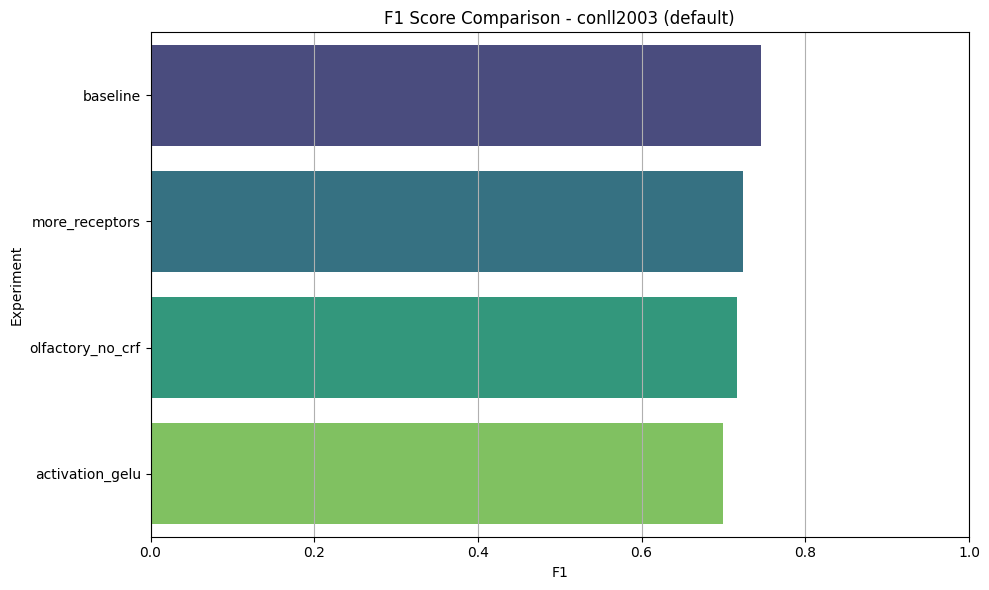

In [6]:
# @title 4. Compare Results (Plotting)
# ==============================================================================
import seaborn as sns

if not df.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='F1', y='Experiment', data=df.sort_values('F1', ascending=False), palette='viridis')
    plt.title(f'F1 Score Comparison - {dataset_name} ({language})')
    plt.xlim(0, 1.0)
    plt.grid(axis='x')
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, 'f1_comparison.png'))
    plt.show()